In [11]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import START,END,StateGraph
from pydantic import BaseModel,Field
from typing import TypedDict,Literal,Annotated
from langchain_core.messages import BaseMessage,HumanMessage
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

In [12]:
load_dotenv()
model=ChatGoogleGenerativeAI(
     model="gemini-3-flash-preview"
)

In [13]:
from langgraph.graph.message import add_messages
class chatbotState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [14]:
def chat_node(state:chatbotState)->chatbotState:
    response=model.invoke(state['messages'])
    return {'messages':[response]}

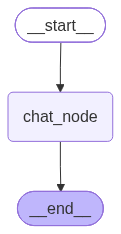

In [25]:
checkpointer = InMemorySaver()
store = InMemoryStore()

graph=StateGraph(chatbotState)
graph.add_node('chat_node',chat_node)
graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

workflow=graph.compile(checkpointer=checkpointer,store=store)
workflow

In [26]:
thread_id='1'
while True:
    user_inp=input('type here')
    print(user_inp)
    if user_inp.lower() in ['quit','exit','bye','stop']:
        break
    config={'configurable':{'thread_id':thread_id}}
    response=workflow.invoke({'messages':[HumanMessage(content=user_inp)]},config=config)
    print(response['messages'][-1].text)
  

what is fact of 5
If you are referring to the mathematical **factorial** of 5 (written as **5!**), the answer is:

**5! = 5 × 4 × 3 × 2 × 1 = 120**

***

If you are looking for **interesting facts** about the number 5, here are a few:

1.  **Human Biology:** Humans typically have 5 fingers on each hand, 5 toes on each foot, and 5 basic senses (sight, hearing, smell, taste, and touch).
2.  **Mathematics:** 5 is the third prime number (after 2 and 3). It is also the only prime number that ends in the digit 5.
3.  **Nature:** Many flowers have 5 petals (like buttercups and apple blossoms), and starfish typically have 5 arms.
4.  **Sports:** A basketball team has 5 players on the court at one time. There are also 5 rings on the Olympic flag, representing the five inhabited continents.
5.  **Music:** A musical staff (where notes are written) consists of 5 horizontal lines.
what is 120 here
In the context of the previous answer, **120** is the **result (the total value)** of calculating **5 

In [32]:
workflow.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='what is fact of 5', additional_kwargs={}, response_metadata={}, id='b659619d-f61d-4ab5-bf43-72520dcdfae4'), AIMessage(content=[{'type': 'text', 'text': 'If you are referring to the mathematical **factorial** of 5 (written as **5!**), the answer is:\n\n**5! = 5 × 4 × 3 × 2 × 1 = 120**\n\n***\n\nIf you are looking for **interesting facts** about the number 5, here are a few:\n\n1.  **Human Biology:** Humans typically have 5 fingers on each hand, 5 toes on each foot, and 5 basic senses (sight, hearing, smell, taste, and touch).\n2.  **Mathematics:** 5 is the third prime number (after 2 and 3). It is also the only prime number that ends in the digit 5.\n3.  **Nature:** Many flowers have 5 petals (like buttercups and apple blossoms), and starfish typically have 5 arms.\n4.  **Sports:** A basketball team has 5 players on the court at one time. There are also 5 rings on the Olympic flag, representing the five inhabited continents.\n5.  